# Car Evaluation Dataset

| Column Name   | Description |
|---------------|-------------|
| buying_price  | Buying price of the car |
| maint_cost    | Maintenance cost of the car |
| doors         | Number of doors |
| persons       | Number of persons the car can carry |
| lug_boot      | Size of the luggage boot |
| safety        | Estimated safety level of the car |
| class         | Car acceptability class (target variable) |

In [105]:
#Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
df = pd.read_csv("car_evaluation.csv")

In [107]:
df

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [108]:
df.describe()

,vhigh,vhigh.1,2,2.1,small,low,unacc
count,1727,1727,1727,1727,1727,1727,1727
unique,4,4,4,3,3,3,4
top,high,high,3,4,med,med,unacc
freq,432,432,432,576,576,576,1209


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vhigh    1727 non-null   object
 1   vhigh.1  1727 non-null   object
 2   2        1727 non-null   object
 3   2.1      1727 non-null   object
 4   small    1727 non-null   object
 5   low      1727 non-null   object
 6   unacc    1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


## Preprocessing

In [110]:
for column in df.columns:
    print(f"{column} : {df[column].unique()}")

vhigh : ['vhigh' 'high' 'med' 'low']
vhigh.1 : ['vhigh' 'high' 'med' 'low']
2 : ['2' '3' '4' '5more']
2.1 : ['2' '4' 'more']
small : ['small' 'med' 'big']
low : ['med' 'high' 'low']
unacc : ['unacc' 'acc' 'vgood' 'good']


In [111]:
df.rename(columns= {
    "vhigh" : "buying_price",
    "vhigh.1" : "maint_cost",
    "2" : "doors",
    "2.1" : "persons",
    "small" : "lug_boot",
    "low" : "safety",
    "unacc" : "class"
    },inplace= True)

In [112]:
df

,buying_price,maint_cost,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5more,more,med,med,good
1723,low,low,5more,more,med,high,vgood
1724,low,low,5more,more,big,low,unacc
1725,low,low,5more,more,big,med,good


In [113]:
df["doors"] = df["doors"].replace("5more", "5")
df["persons"] = df["persons"].replace("more", "5")

In [114]:
df["doors"] = df["doors"].astype("int")
df["persons"] = df["persons"].astype("int")

In [115]:
df

,buying_price,maint_cost,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc
...,...,...,...,...,...,...,...
1722,low,low,5,5,med,med,good
1723,low,low,5,5,med,high,vgood
1724,low,low,5,5,big,low,unacc
1725,low,low,5,5,big,med,good


## Simple Exploratory Data Analysis(EDA)

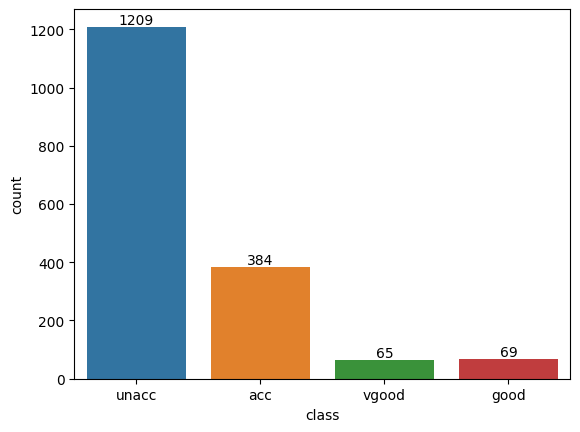

In [116]:
ax = sns.countplot(
    data= df,
    x = "class",
    hue= "class"
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

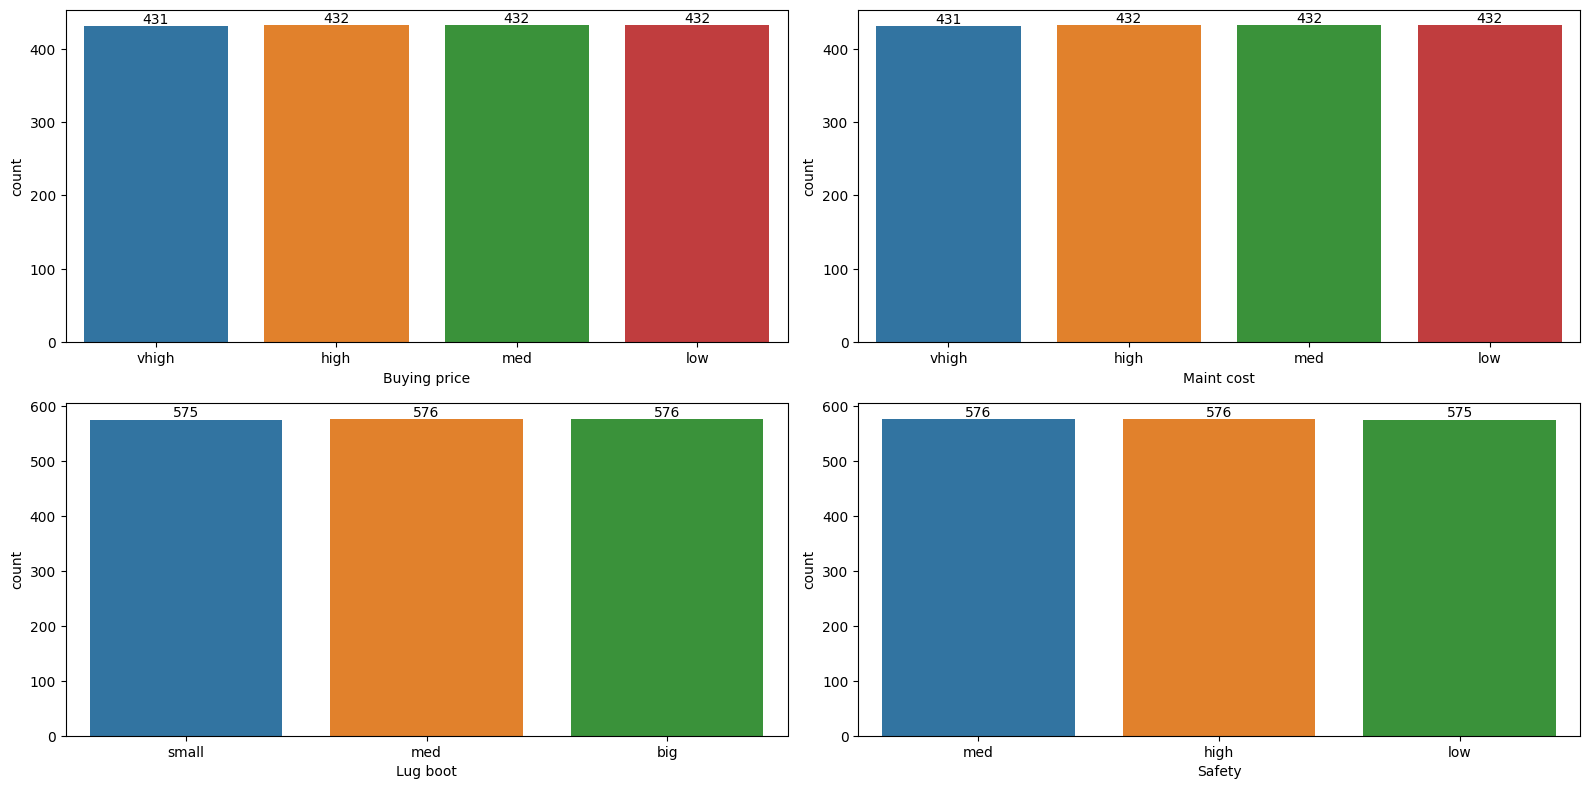

In [117]:
categoric_cols = ["buying_price", "maint_cost", "lug_boot", "safety"]


fig ,ax = plt.subplots(2, 2, figsize = (16, 8))
ax = ax.ravel()

for index, col in enumerate(categoric_cols, 0):
    axis = sns.countplot(
        data = df,
        x= col,
        hue= col,
        ax = ax[index]
    )

    axis.set_xlabel((categoric_cols[index].replace("_", " ")).capitalize())

    for container in axis.containers:
        axis.bar_label(container)

plt.tight_layout()
plt.show()

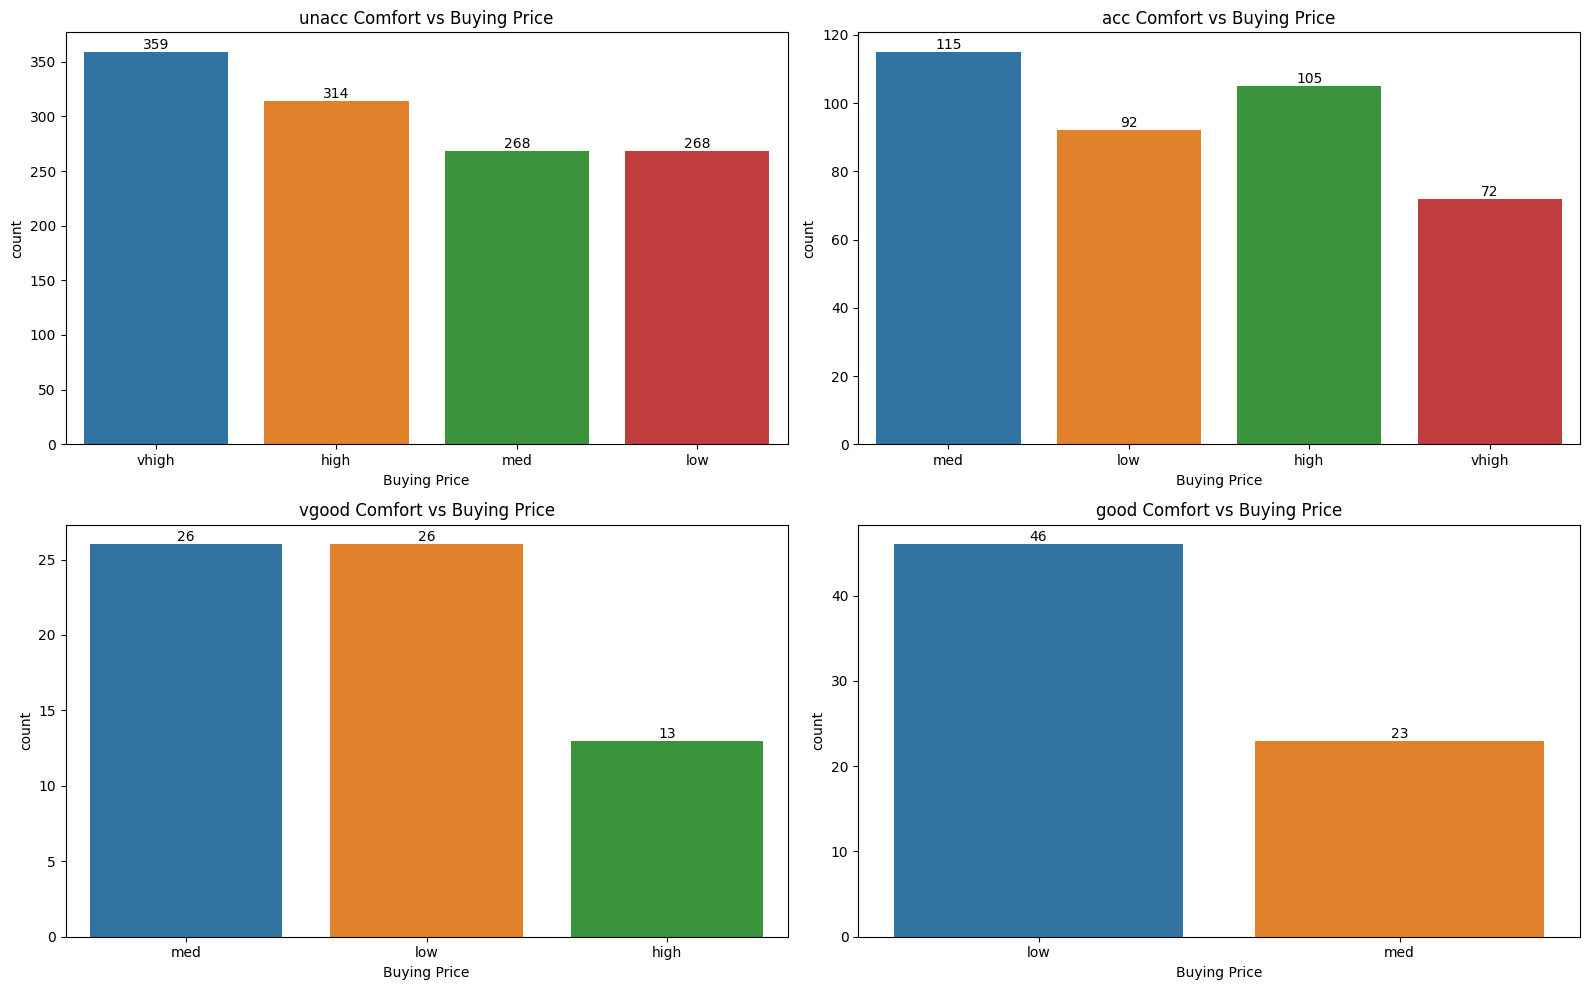

In [118]:
values = df["class"].unique()

fig, ax = plt.subplots(2, 2, figsize = (16, 10))
ax = ax.ravel()

for index, value in enumerate(values):
    axis = sns.countplot(
        data= df[df["class"] == value],
        x= "maint_cost",
        hue = "maint_cost",
        ax = ax[index]
    )

    for container in axis.containers:
        axis.bar_label(container)

    axis.set_title(f"{value} Comfort vs Buying Price")
    axis.set_xlabel("Buying Price")


plt.tight_layout()
plt.show()

## Training

In [119]:
X = df.drop("class", axis= 1)
y = df["class"]

In [120]:
from sklearn.model_selection import train_test_split

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [122]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [123]:
categoric_cols = ["buying_price", "maint_cost", "lug_boot", "safety"]
numeric_cols = ["doors", "persons"]

In [124]:
ordinal_encoder = OrdinalEncoder(
    categories= [
        ["low", "med", "high", "vhigh"], #buying_price
        ["low", "med", "high", "vhigh"], #maint_cost
        ["small", "med", "big"], #lug_boot
        ["low", "med", "high"], #safety
    ]
)


In [125]:
preprocessor = ColumnTransformer(
    transformers= [
        ("transformation_name", ordinal_encoder, categoric_cols)
        # ("transformation_name", ohe, categoric_cols),
        # ("transformation_name", label_encoder, categoric_cols),
    ],
    remainder= "passthrough" # df içinde encode etmediği kolonları drop etmemesi için
)

In [126]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [127]:
X_train_transformed

array([[3., 2., 0., 0., 2., 2.],
       [1., 3., 0., 1., 3., 4.],
       [0., 0., 2., 2., 5., 2.],
       ...,
       [2., 0., 2., 0., 5., 5.],
       [0., 2., 0., 2., 4., 2.],
       [1., 1., 0., 2., 3., 5.]], shape=(1381, 6))

In [128]:
from sklearn.tree import DecisionTreeClassifier

In [129]:
tree_model = DecisionTreeClassifier(max_depth= 3)

tree_model.fit(X_train_transformed, y_train)

DecisionTreeClassifier(max_depth=3)

In [130]:
predicts = tree_model.predict(X_test_transformed)

In [131]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [132]:
print(f"Score : {accuracy_score(y_test, predicts):.2%}")
print(f"Classification Report :\n{classification_report(y_test, predicts)}")
print(f"Confusion Matrix :\n{confusion_matrix(y_test, predicts)}")


Score : 81.21%
Classification Report :
              precision    recall  f1-score   support

         acc       0.57      0.64      0.60        77
        good       0.00      0.00      0.00        15
       unacc       0.89      0.98      0.93       237
       vgood       0.00      0.00      0.00        17

    accuracy                           0.81       346
   macro avg       0.37      0.40      0.38       346
weighted avg       0.74      0.81      0.77       346

Confusion Matrix :
[[ 49   0  28   0]
 [ 15   0   0   0]
 [  5   0 232   0]
 [ 17   0   0   0]]


[Text(0.3333333333333333, 0.875, 'safety <= 0.5\ngini = 0.452\nsamples = 1381\nvalue = [307, 54, 972, 48]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 467\nvalue = [0, 0, 467, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'persons <= 3.0\ngini = 0.576\nsamples = 914\nvalue = [307, 54, 505, 48]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 299\nvalue = [0, 0, 299, 0]'),
 Text(0.6666666666666666, 0.375, 'buying_price <= 1.5\ngini = 0.625\nsamples = 615\nvalue = [307, 54, 206, 48]'),
 Text(0.5, 0.125, 'gini = 0.652\nsamples = 298\nvalue = [155, 54, 41, 48]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.499\nsamples = 317\nvalue = [152, 0, 165, 0]')]

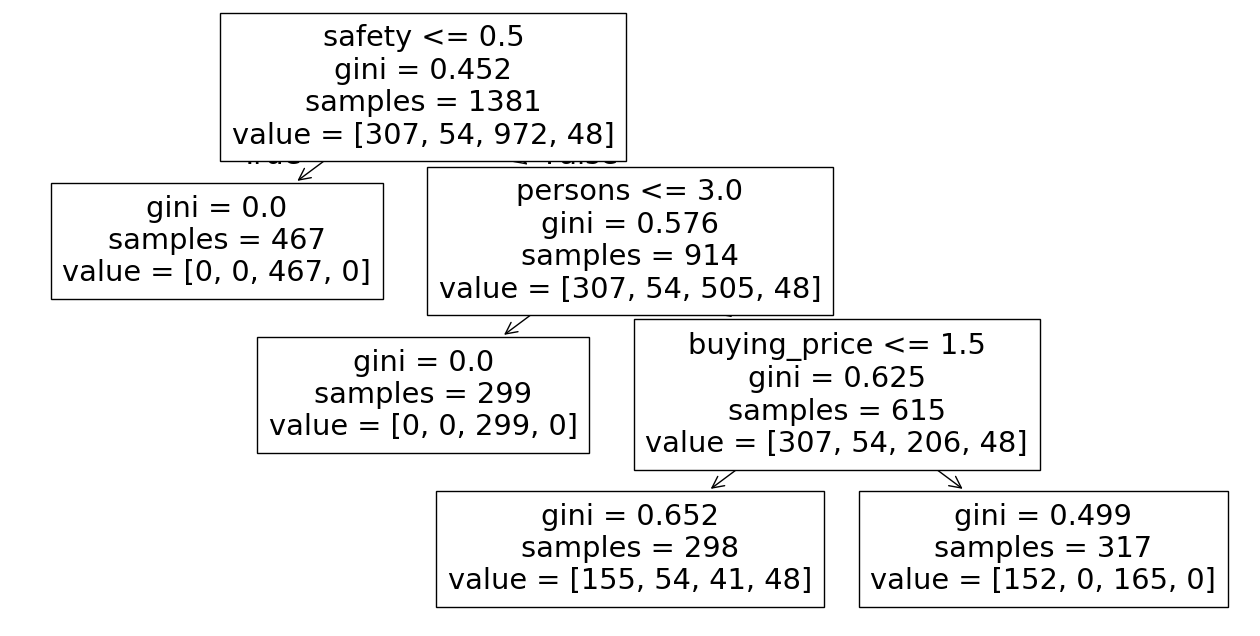

In [133]:
plt.figure(figsize= (16, 8))

from sklearn import tree

column_names = categoric_cols + numeric_cols
tree.plot_tree(tree_model.fit(X_train_transformed, y_train), feature_names= column_names)

In [134]:
#Hyperparam Tuning

In [135]:
criterion = ["gini", "entropy", "log_loss"]
splitter = ["best", "random"]
max_depth = [1, 3 ,5 ,7, 15, None]
max_features = ["sqrt", "log2", None]

In [136]:
params = dict(
    criterion = criterion,
    splitter = splitter,
    max_depth = max_depth,
    max_features = max_features
)

In [137]:
params

{'criterion': ['gini', 'entropy', 'log_loss'],
 'splitter': ['best', 'random'],
 'max_depth': [1, 3, 5, 7, 15, None],
 'max_features': ['sqrt', 'log2', None]}

In [138]:
from sklearn.model_selection import GridSearchCV
import warnings

warnings.filterwarnings("ignore")

In [139]:
grid = GridSearchCV(
    estimator= DecisionTreeClassifier(),
    param_grid= params,
    cv= 5,
    n_jobs= -1,
    scoring= "accuracy"
)

In [140]:
grid.fit(X_train_transformed, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 3, 5, 7, 15, None],
                         'max_features': ['sqrt', 'log2', None],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [141]:
grid.best_estimator_

DecisionTreeClassifier(criterion='log_loss', max_depth=15)

In [142]:
grid.best_params_

{'criterion': 'log_loss',
 'max_depth': 15,
 'max_features': None,
 'splitter': 'best'}

In [143]:
predicts = grid.predict(X_test_transformed)

In [144]:
print(f"Score : {accuracy_score(y_test, predicts):.2%}")
print(f"Classification Report :\n{classification_report(y_test, predicts)}")
print(f"Confusion Matrix :\n{confusion_matrix(y_test, predicts)}")

Score : 96.53%
Classification Report :
              precision    recall  f1-score   support

         acc       0.96      0.92      0.94        77
        good       0.75      0.80      0.77        15
       unacc       0.99      1.00      0.99       237
       vgood       0.83      0.88      0.86        17

    accuracy                           0.97       346
   macro avg       0.88      0.90      0.89       346
weighted avg       0.97      0.97      0.97       346

Confusion Matrix :
[[ 71   2   2   2]
 [  2  12   0   1]
 [  1   0 236   0]
 [  0   2   0  15]]


In [145]:
tree_model_new = DecisionTreeClassifier(
criterion= 'entropy',
max_depth = 15,
max_features =  None,
splitter ='best')

In [146]:
tree_model_new.fit(X_train_transformed, y_train)
predicts = tree_model_new.predict(X_test_transformed)

print(f"Score : {accuracy_score(y_test, predicts):.2%}")
print(f"Classification Report :\n{classification_report(y_test, predicts)}")
print(f"Confusion Matrix :\n{confusion_matrix(y_test, predicts)}")


Score : 96.53%
Classification Report :
              precision    recall  f1-score   support

         acc       0.96      0.92      0.94        77
        good       0.75      0.80      0.77        15
       unacc       0.99      1.00      0.99       237
       vgood       0.83      0.88      0.86        17

    accuracy                           0.97       346
   macro avg       0.88      0.90      0.89       346
weighted avg       0.97      0.97      0.97       346

Confusion Matrix :
[[ 71   2   2   2]
 [  2  12   0   1]
 [  1   0 236   0]
 [  0   2   0  15]]


[Text(0.6060606060606061, 0.9615384615384616, 'safety <= 0.5\nentropy = 1.19\nsamples = 1381\nvalue = [307, 54, 972, 48]'),
 Text(0.5909090909090909, 0.8846153846153846, 'entropy = 0.0\nsamples = 467\nvalue = [0, 0, 467, 0]'),
 Text(0.5984848484848485, 0.9230769230769231, 'True  '),
 Text(0.6212121212121212, 0.8846153846153846, 'persons <= 3.0\nentropy = 1.466\nsamples = 914\nvalue = [307, 54, 505, 48]'),
 Text(0.6136363636363636, 0.9230769230769231, '  False'),
 Text(0.6060606060606061, 0.8076923076923077, 'entropy = 0.0\nsamples = 299\nvalue = [0, 0, 299, 0]'),
 Text(0.6363636363636364, 0.8076923076923077, 'buying_price <= 1.5\nentropy = 1.624\nsamples = 615\nvalue = [307, 54, 206, 48]'),
 Text(0.4090909090909091, 0.7307692307692307, 'maint_cost <= 1.5\nentropy = 1.755\nsamples = 298\nvalue = [155, 54, 41, 48]'),
 Text(0.2159090909090909, 0.6538461538461539, 'safety <= 1.5\nentropy = 1.773\nsamples = 150\nvalue = [49, 54, 7, 40]'),
 Text(0.09090909090909091, 0.5769230769230769, 'lug_

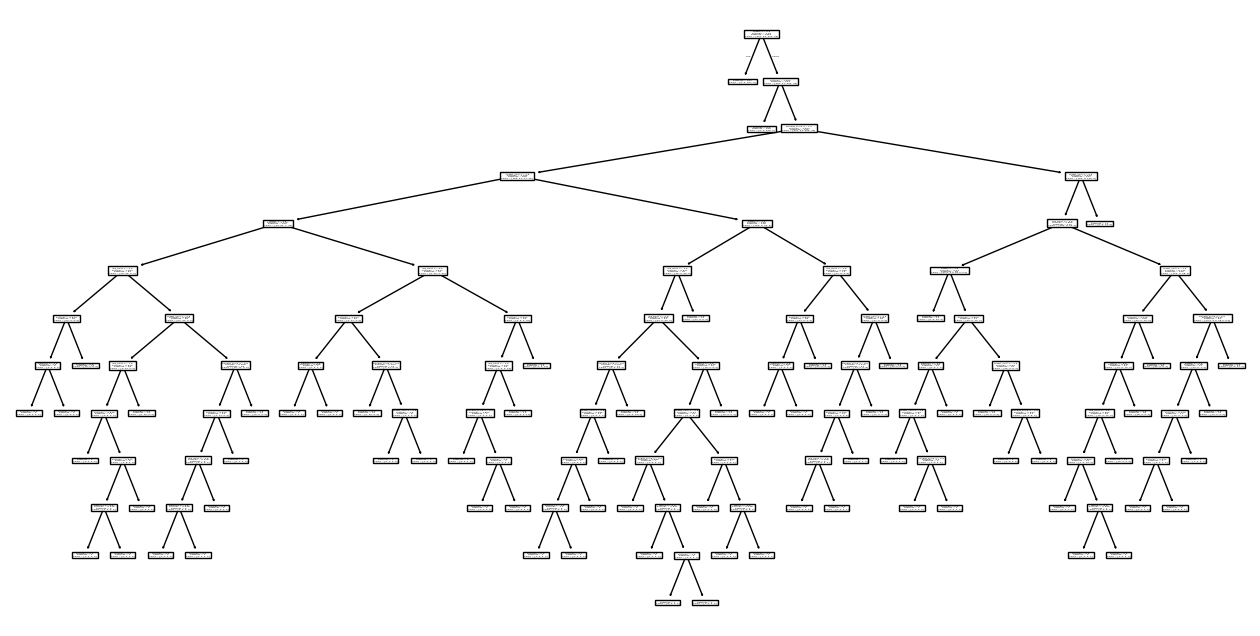

In [147]:
plt.figure(figsize= (16, 8))


column_names = categoric_cols + numeric_cols
tree.plot_tree(tree_model_new.fit(X_train_transformed, y_train), feature_names= column_names)